Massive parallel programming on GPUs and applications, by Lokman ABBAS TURKI  

# 2. Hello World! and built-in variables

## 2.1 Objective

The main purpose of this lab is to show the multi-granularity parallelization in CUDA involving blocks, threads, and warps. We show this multi-granularity using an easy example of printing built-in variables. The "printf" function on the device is also studied as well as other GPU specifications that can be obtained with fast "cudaDeviceGetAttribute". When printing built-in variables, feel free to test your own if statement.

As usual, I urge students to open CUDA documentation, especially:

1) the specifications of CUDA API functions within the [CUDA_Runtime_API](https://docs.nvidia.com/cuda/cuda-runtime-api/index.html).
2) the examples of how to use the CUDA API functions in [CUDA_C_Programming_Guide](https://docs.nvidia.com/cuda/cuda-c-programming-guide/index.html)

## 2.2 Content

Compile HWbuilt.cu using


In [ ]:
!nvcc HWbuilt.cu -o HW


Execute HW using (on Windows machine ./ is not needed)


In [4]:
!./HW

As long as you did not include any additional instruction in the file HWbuilt.cu, the execution above is not supposed to return any value. At least, no compilation error is detected by the compiler!

In the following questions, you will need to include your own code in the file HWbuilt.cu, then compile it and execute it before answering.


### 2.2.1 In the main function, use `cudaDeviceGetAttribute` and then `cudaDeviceGetLimit` to display 

a) The major Y and the minor y of the device compute capability. Explain why this is faster than using `cudaGetDeviceProperties`.

**Answer**: This is faster because `cudaDeviceGetAttribute` calls a single attribute, whereas `cudaGetDeviceProperties` retrieves all the data structure of the device.

b) The size of the FIFO buffer of the data transferred to the host when executing printf() on the device. Explain then why should we use cudaDeviceSynchronize on the host when calling printf() on the device.


<b><font color='red'>In the following questions, all compilations will be performed using the compilation options

-arch=compute_60 -code=sm_Yy

, with Y and y from question 1.2.1.a. For example</font> </b>

In [ ]:
!nvcc HWbuilt.cu -arch=compute_60 -code=sm_75 -o HW

### 2.2.2 Printing Hello World! and built-in variables

a) Fill the kernel print_k with the appropriate code to print "Hello World!" and then call it within the main function.

b) What happens when you call print_k with two blocks and four threads per block?

**Answer**: It prints it $8$ times.

c) Instead of printing "Hello World!", print the values of threadIdx.x, blockDim.x, blockIdx.x, and gridDim.x.

d) With two blocks and four threads per block, execute the code of question c) multiple times. What do you remark?

**Answer**: At each iteration, `threadIdx.x` is incremented by $1$, starting from $0$ up to $3$. This cycle of values $(0, 1, 2, 3)$ is repeated twice during program execution. 

`blockDim.x` takes the value $4$ at each iteration, it is the number of threads run in parallel within a single block. 

`blockId.x` is the identifier of the block that run the thread displaying the output. It takes the value $0$ for the first 4 iterations, and the value $1$ for the $4$ last iterations.

`gridDim.x` takes the value $2$ at each iteration. It is the number of blocks running on the device.


### 2.2.3 More built-in variables printing with 64 blocks and 64 threads per block

a) In `print_k`, write an if sentence that excludes all threads from printing except threads $0$.

b) Execute the code of the question a) multiple times. What do you remark?

**Answer**: The order in which the threads are displayed can change from one run to the next. This is due to the asynchronous nature of the connection between the host and the device and that threads are run in parallel. I expect the threads to be executed within the same warp.

c) In `print_k`, write an if sentence that excludes all blocks from printing except block $0$.

d) Execute the code of the question c) multiple times. What do you remark?

**Answer**: This time, the display order remains the same for each run. Apparently, it is supposed to vary.

e) From questions c) and d), what is the number of threads (lanes or threads of the same warp) that execute in lockstep?

**Answer**: What is a lockstep? A lockstep system is a fault-tolerant system that runs multiple copies the same set of operations at the same time in parallel



f) What if you answer questions c)d)e) and compile your code with `-arch=compute_Yy -code=sm_Yy`, with $Yy>60$? What happens?

**Answer**: That's already what I did, since Colab GPU compute capability is already above $60$.

### 2.2.4 Your index variables using built-in variables

a) Defines an index variable to distinguish lanes (threads within the same warp).

**Answer**: The index is $\text{idx}=$<code>threadIdx.x</code> $\% \, 32$.

b) Defines an index variable to distinguish warps within one block.

**Answer**: The index is $\text{idx}=$`threadIdx.x` $//\, \, 32$

c) Defines an index variable to distinguish warps within the whole grid.

**Answer**: This is the classical index to access lists: $\text{idx}=$`threadIdx.x`+ `blockDim.x`*`blockIdx.x`.

d) In what memory space are these variables stored?

**Answer**: They should be stored in the **register file**.

e) What happens to indices in a)b)c) when we replace warps with $n$ consecutive threads?

**Answer**: All formulas are the same, simply replace $32$ with $n$.

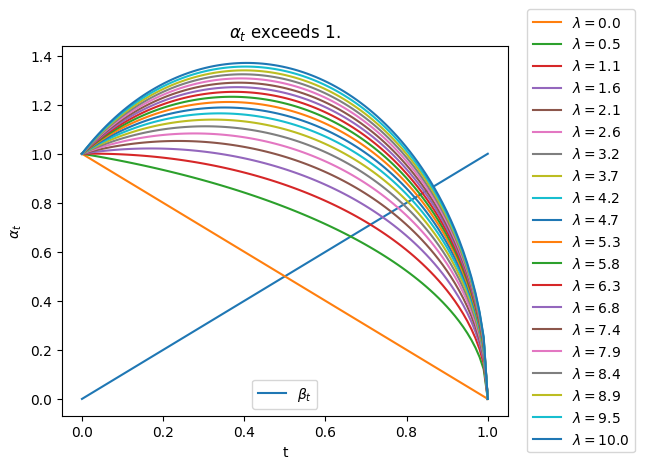

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def alpha(t: float, lamda: float):
    assert lamda >= 0
    return np.sqrt((1-2*np.sqrt(lamda))*t**2 + 2*(np.sqrt(lamda) - 1)*t + 1)

def beta(t):
    return t

lamda=np.linspace(0, 10, 20)
t=np.linspace(0, 1, 100)

fig=plt.figure()
ax=fig.add_subplot(1, 1, 1)

lines1, =ax.plot(t, beta(t), label="$\\beta_t$")

first_legend=ax.legend(handles=[lines1], loc='lower center')

# Add the legend manually to the Axes.
ax.add_artist(first_legend)

lines=[]

for l in lamda:
    line, =ax.plot(t, alpha(t, l), label=f'$\\lambda={l:.1f}$')
    lines += [line]

ax.set_xlabel("t")
ax.set_ylabel("$\\alpha_t$")
# Add a legend
pos = ax.get_position()
ax.set_position([pos.x0, pos.y0, pos.width * 0.9, pos.height])
ax.legend(handles=lines, loc='center right', bbox_to_anchor=(1.3, 0.5))

ax.set_title("$\\alpha_t$ exceeds 1.")

plt.show()

fig.savefig("alpha_t.png", bbox_inches='tight')

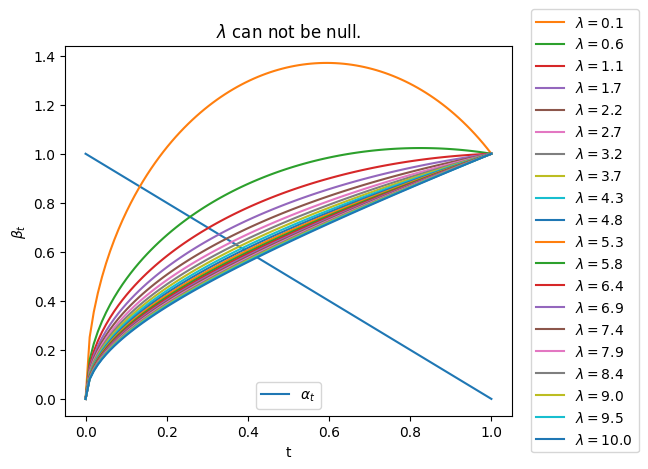

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def alpha(t: float):
    return 1-t

def beta(t: float, lamda: float):
    sqrt_lam=np.sqrt(lamda)
    return np.sqrt(t/sqrt_lam*((sqrt_lam - 2)*t+2))

lamda=np.linspace(0.1, 10, 20)
t=np.linspace(0, 1, 100)

fig=plt.figure()
ax=fig.add_subplot(1, 1, 1)

lines1, =ax.plot(t, alpha(t), label="$\\alpha_t$")

first_legend=ax.legend(handles=[lines1], loc='lower center')

# Add the legend manually to the Axes.
ax.add_artist(first_legend)

lines=[]

for l in lamda:
    line, =ax.plot(t, beta(t, l), label=f'$\\lambda={l:.1f}$')
    lines+=[line]

ax.set_xlabel("t")
ax.set_ylabel("$\\beta_t$")

# Add a legend
pos = ax.get_position()
ax.set_position([pos.x0, pos.y0, pos.width * 0.9, pos.height])
ax.legend(handles=lines, loc='center right', bbox_to_anchor=(1.3, 0.5))

ax.set_title("$\\lambda$ can not be null.")

plt.show()

fig.savefig("beta_t.png", bbox_inches='tight')

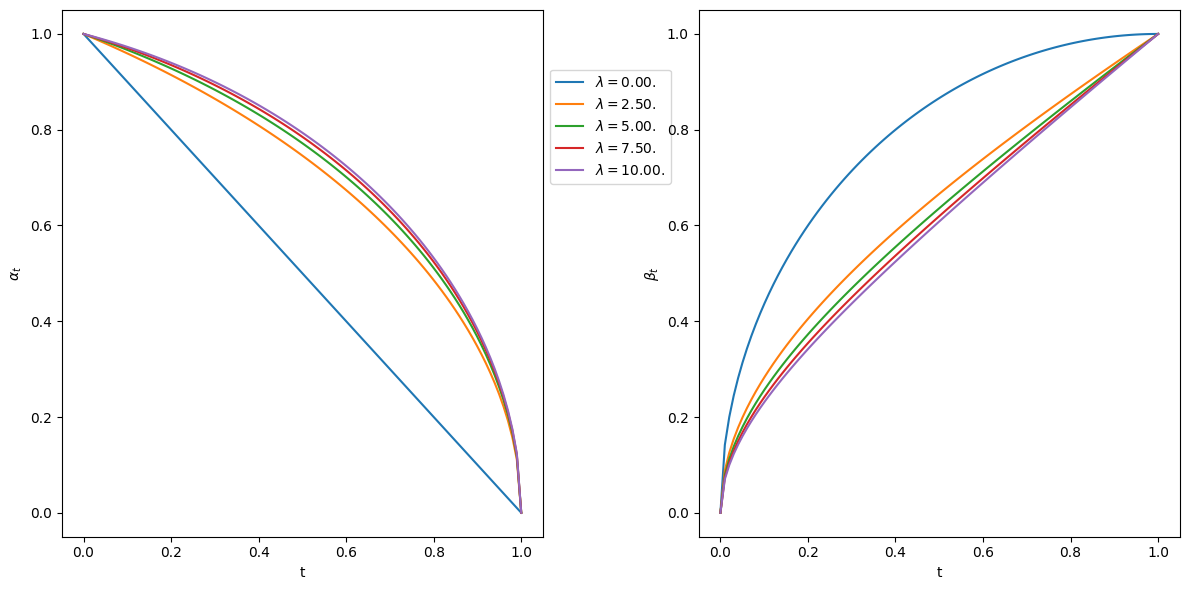

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def alpha(t: float, lamda: float):
    sqrt_lamda=np.sqrt(lamda)
    return np.sqrt((1-sqrt_lamda)/(sqrt_lamda+1)*t**2 - 2/(sqrt_lamda + 1)*t+1)

def beta(t: float, lamda: float):
    sqrt_lamda=np.sqrt(lamda)
    return np.sqrt(t/(sqrt_lamda + 1)*((sqrt_lamda - 1)*t + 2))

lamda=np.linspace(0, 10, 5)
t=np.linspace(0, 1, 100)

fig=plt.figure(figsize=(12, 6))
ax=fig.add_subplot(1, 2, 1)
ax2=fig.add_subplot(1, 2, 2)

lines=[]

for l in lamda:
    line1, =ax.plot(t, alpha(t, l), label=f"$\\lambda={l:.2f}$.")
    ax2.plot(t, beta(t, l))
    lines+=[line1]

ax.set_xlabel("t")
ax.set_ylabel("$\\alpha_t$")

ax2.set_xlabel("t")
ax2.set_ylabel("$\\beta_t$")

# Add a legend
pos = ax.get_position()
ax.set_position([pos.x0, pos.y0, pos.width * 0.9, pos.height])
ax.legend(handles=lines, loc='upper left', bbox_to_anchor=(1, 0.9))

plt.tight_layout()
plt.show()

fig.savefig("beta_t.png", bbox_inches='tight')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def alpha_sq(t: float, lamda: float):
    sqrt_lamda=np.sqrt(lamda)
    return (1-sqrt_lamda)/(sqrt_lamda+1)*t**2 - 2/(sqrt_lamda + 1)*t+1

def beta_sq(t: float, lamda: float):
    sqrt_lamda=np.sqrt(lamda)
    return t/(sqrt_lamda + 1)*((sqrt_lamda - 1)*t + 2)


fig, ax = plt.subplots()

lamda1=2.5

lamda2=1

t = np.linspace(0, 2*np.pi, 200)
line, = ax.plot([], [])

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')

def update(frame):
    a = alpha_sq(t, lamda1) + beta_sq(t, lamda1)*lamda1   # demi-grand axe
    b = alpha_sq(t, lamda2) + beta_sq(t, lamda2)*lamda2   # demi-petit axe
    
    x = a * np.cos(t)
    y = b * np.sin(t)
    
    line.set_data(x, y)
    return line,

ani = FuncAnimation(fig, update, frames=np.linspace(0, 2*np.pi, 100), interval=50)

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def alpha_sq(t: float, lamda: float):
    return (lamda - lamda**t)/(lamda - 1)

def beta_sq(t: float, lamda: float):
    return (lamda**t - 1)/(lamda - 1)


fig, ax = plt.subplots()

lamda1=2.5

lamda2=1

t = np.linspace(0, 2*np.pi, 200)
line, = ax.plot([], [])

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')

def update(frame):
    a = alpha_sq(t, lamda1) + beta_sq(t, lamda1)*lamda1   # demi-grand axe
    b = alpha_sq(t, lamda2) + beta_sq(t, lamda2)*lamda2   # demi-petit axe
    
    x = a * np.cos(t)
    y = b * np.sin(t)
    
    line.set_data(x, y)
    return line,

ani = FuncAnimation(fig, update, frames=np.linspace(0, 2*np.pi, 100), interval=50)

plt.show()